<a href="https://colab.research.google.com/github/Malek720/MachineLearning/blob/main/adult.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRISP-DM Data Science Project: UCI Adult Income Analysis & Segmentation

## 1. Business Understanding

### Business Problem
Accurately predicting individual income levels ($\le$50K vs. >50K) based on demographic and employment attributes is crucial for financial institutions, marketing bodies, and policymakers to deliver targeted financial services and social resource allocations.

### Project Objectives
1. **Predictive Modeling:** Build and evaluate classification models to identify whether an individual earns more than $50,000 annually.
2. **Segmentation:** Group individuals using unsupervised clustering (K-Means) to discover distinct socio-economic profiles.
3. **Data Quality & Transformation:** Resolve missing values, standardize class labels, correct heavy skewness, and output a clean, reproducible dataset (`adult_cleaned_prepared.csv`).

### Evaluation Metrics
- **Primary Metric:** ROC-AUC Score and F1-Score (chosen due to class imbalance where >50K represents ~24% of the population).
- **Secondary Metrics:** Precision, Recall, and Confusion Matrix trade-offs.

In [3]:
# Télécharge les données depuis l'UCI si elles ne sont pas déjà dans la session
import os, urllib.request, zipfile

if not os.path.exists("adult.data"):
    urllib.request.urlretrieve(
        "https://archive.ics.uci.edu/static/public/2/adult.zip", "adult.zip")
    zipfile.ZipFile("adult.zip").extractall(".")

print([f for f in os.listdir(".") if f.startswith("adult")])
import pandas as pd
import numpy as np

# Define official UCI Adult column names (since adult.data has no headers)
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 1. Load training data
df_train = pd.read_csv('adult.data', names=columns, skipinitialspace=True)

# 2. Load test data (skiprow=1 skips the '|1x3 Cross valid' metadata line at the top)
df_test = pd.read_csv('adult.test', names=columns, skiprows=1, skipinitialspace=True)

# 3. Combine into a single complete dataset for preparation
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print(f"Total dataset shape: {df.shape}")
df.head()


['adult.test', 'adult.data']
Total dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# 1. Inspect data types and missing structure
print("--- Data Summary ---")
df.info()

# 2. Check distributions of continuous variables
print("\n--- Summary Statistics ---")
display(df.describe().T)

# 3. Inspect unique values in categorical columns to spot '?'
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}' unique count: {df[col].nunique()}")
    if '?' in df[col].values:
        missing_count = (df[col] == '?').sum()
        print(f"   ⚠️ Contains {missing_count} '?' values ({missing_count/len(df):.2%})")

--- Data Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


Column 'workclass' unique count: 9
   ⚠️ Contains 2799 '?' values (5.73%)
Column 'education' unique count: 16
Column 'marital-status' unique count: 7
Column 'occupation' unique count: 15
   ⚠️ Contains 2809 '?' values (5.75%)
Column 'relationship' unique count: 6
Column 'race' unique count: 5
Column 'sex' unique count: 2
Column 'native-country' unique count: 42
   ⚠️ Contains 857 '?' values (1.75%)
Column 'income' unique count: 4


In [5]:
# 1. Inspect data types and missing structure
print("--- Data Summary ---")
df.info()

# 2. Check distributions of continuous variables
print("\n--- Summary Statistics ---")
display(df.describe().T)

# 3. Inspect unique values in categorical columns to spot '?'
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}' unique count: {df[col].nunique()}")
    if '?' in df[col].values:
        missing_count = (df[col] == '?').sum()
        print(f"   ⚠️ Contains {missing_count} '?' values ({missing_count/len(df):.2%})")

--- Data Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


Column 'workclass' unique count: 9
   ⚠️ Contains 2799 '?' values (5.73%)
Column 'education' unique count: 16
Column 'marital-status' unique count: 7
Column 'occupation' unique count: 15
   ⚠️ Contains 2809 '?' values (5.75%)
Column 'relationship' unique count: 6
Column 'race' unique count: 5
Column 'sex' unique count: 2
Column 'native-country' unique count: 42
   ⚠️ Contains 857 '?' values (1.75%)
Column 'income' unique count: 4


/tmp/ipykernel_2003/2130949836.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='income', palette='Set2')


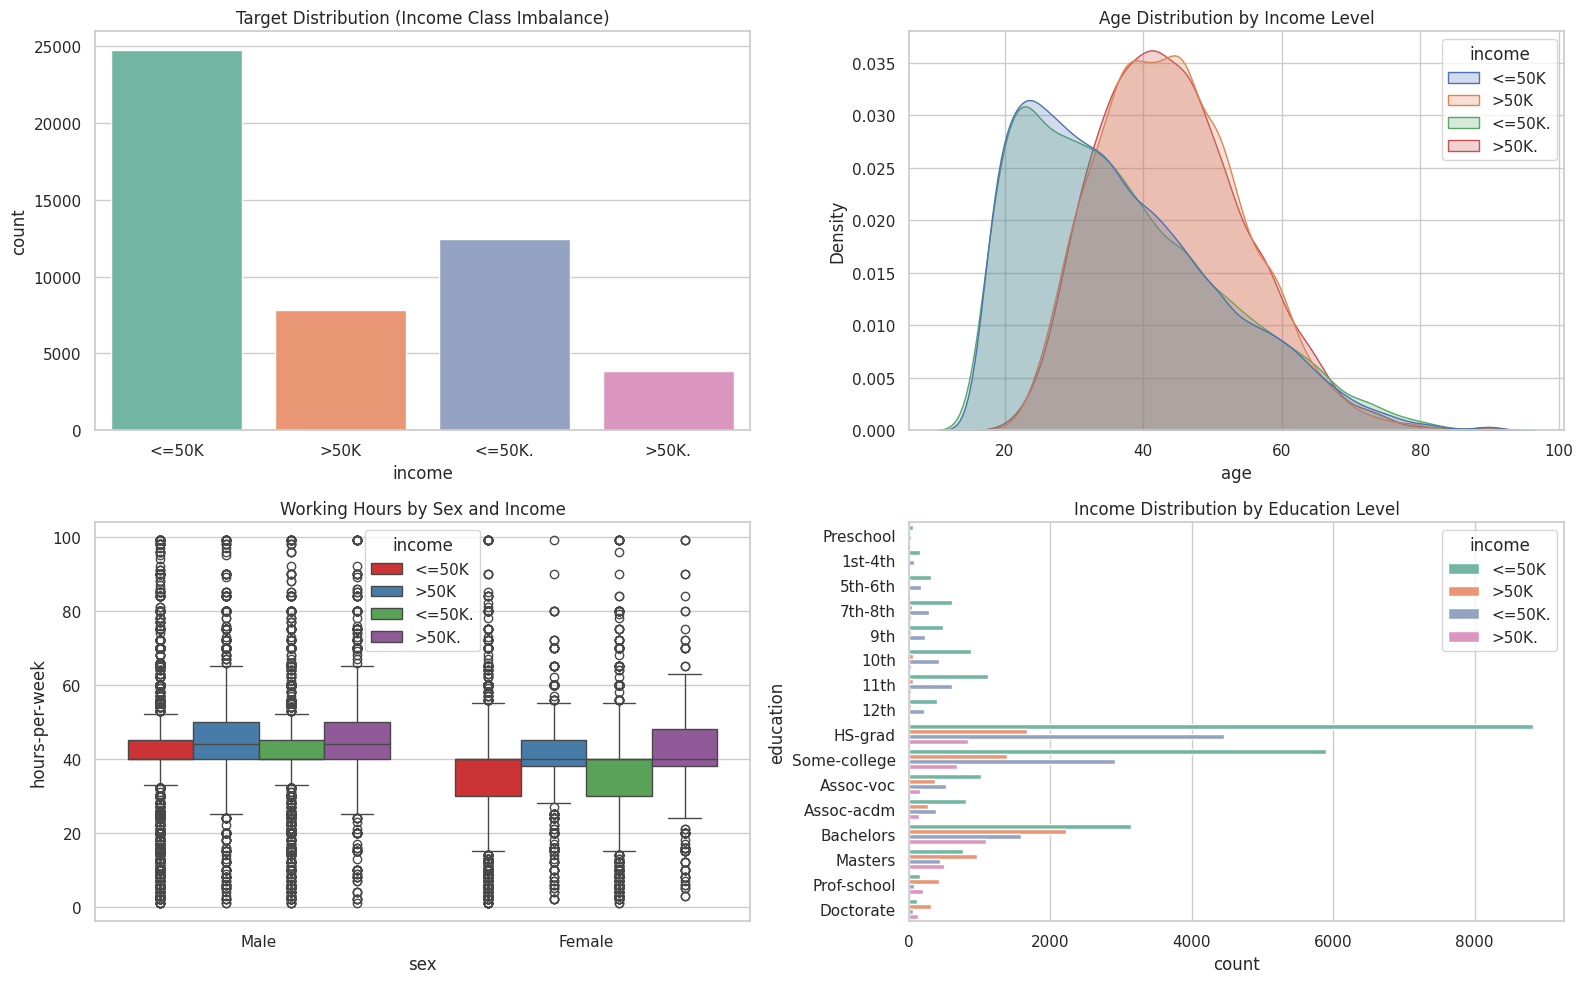

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# 1. Target Class Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='income', palette='Set2')
plt.title("Target Distribution (Income Class Imbalance)")

# 2. Age distribution by Income
plt.subplot(2, 2, 2)
sns.kdeplot(data=df, x='age', hue='income', fill=True, common_norm=False)
plt.title("Age Distribution by Income Level")

# 3. Hours per week by Sex and Income
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='sex', y='hours-per-week', hue='income', palette='Set1')
plt.title("Working Hours by Sex and Income")

# 4. Education Level vs Income
plt.subplot(2, 2, 4)
education_order = df.groupby('education')['education-num'].mean().sort_values().index
sns.countplot(data=df, y='education', hue='income', order=education_order, palette='Set2')
plt.title("Income Distribution by Education Level")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Clean Target Strings & Remove Whitespace
# Fixes trailing dots in test set ('>50K.' vs '>50K') and whitespace
df['income'] = df['income'].astype(str).str.strip().str.rstrip('.')

# 2. Convert '?' strings to formal NaNs
df.replace('?', np.nan, inplace=True)

# 3. Handle Missing Values (Mode Imputation for Categorical Features)
# Justification: Missing values account for <6% of rows in workclass, occupation, and native-country.
for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 4. Feature Selection & Multicollinearity Removal
# Justification: 'education-num' is an exact numerical rank of 'education'. Dropping text prevents duplicate columns.
df.drop(columns=['education'], inplace=True)

# 5. Handle Skewness & Outliers in Financial Features
# Justification: Over 90% of values in capital-gain/loss are zero. Log(1+x) stabilizes variance for models.
df['capital-gain-log'] = np.log1p(df['capital-gain'])
df['capital-loss-log'] = np.log1p(df['capital-loss'])
df.drop(columns=['capital-gain', 'capital-loss'], inplace=True)

# 6. Build Preprocessing Pipeline (Scaling & Encoding)
X = df.drop(columns=['income'])
y = (df['income'] == '>50K').astype(int)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

# Fit and transform feature matrix
X_prepared = preprocessor.fit_transform(X)

# 7. Save Cleaned Dataset Deliverable
df.to_csv('adult_cleaned_prepared.csv', index=False)

print("✅ Data Preparation Complete!")
print(f"Prepared Feature Matrix Shape: {X_prepared.shape}")
print(f"Target Class Balance: {np.bincount(y) / len(y)}")
print("Saved cleaned deliverable to 'adult_cleaned_prepared.csv'.")

/tmp/ipykernel_2003/4225672078.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


✅ Data Preparation Complete!
Prepared Feature Matrix Shape: (48842, 82)
Target Class Balance: [0.76071823 0.23928177]
Saved cleaned deliverable to 'adult_cleaned_prepared.csv'.


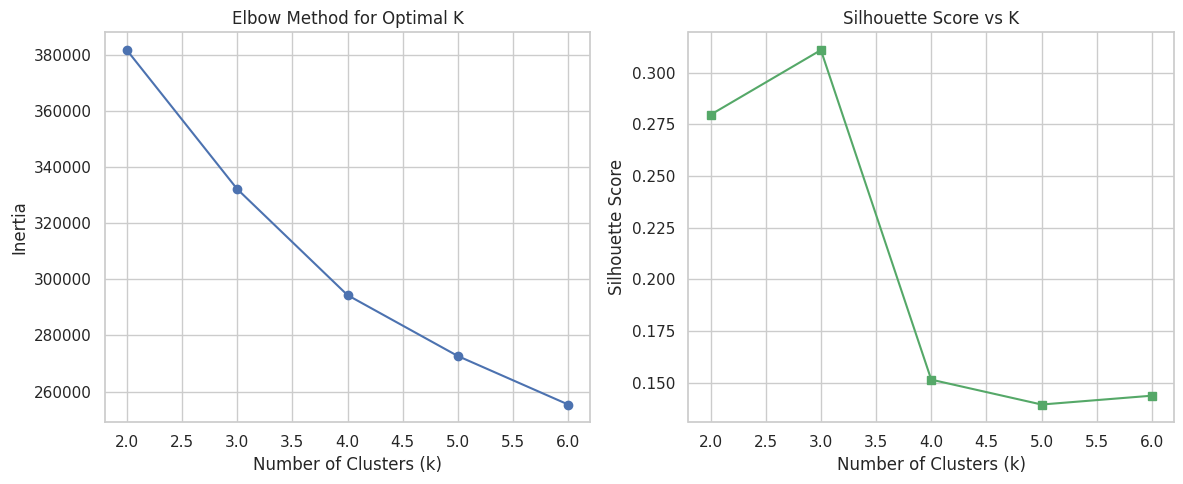

=== Cluster Summary Profiles ===
               age  hours-per-week  capital-gain-log  high_income_ratio
cluster                                                                
0        37.953471       39.974185          0.000931           0.189312
1        44.146511       43.539856          8.826412           0.618575
2        41.795355       43.274759          0.000000           0.501315


In [8]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Determine Optimal K (Elbow Method & Silhouette Analysis)
# Using a sub-sample for Silhouette calculation to optimize performance
sample_mask = np.random.choice(X_prepared.shape[0], size=5000, replace=False)
X_sample = X_prepared[sample_mask]

k_range = range(2, 7)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_prepared)
    inertias.append(kmeans_temp.inertia_)

    # Calculate silhouette score on sample
    score = silhouette_score(X_sample, kmeans_temp.predict(X_sample))
    silhouette_scores.append(score)

# Plot Elbow Curve and Silhouette Scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='g')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# 2. Fit Final K-Means Model (Selecting K=3 based on profile separation)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_prepared)

# 3. Cluster Profiling & Interpretation
print("=== Cluster Summary Profiles ===")
cluster_profile = df.groupby('cluster').agg({
    'age': 'mean',
    'hours-per-week': 'mean',
    'capital-gain-log': 'mean',
    'income': lambda x: (x == '>50K').mean()  # High-income ratio per cluster
}).rename(columns={'income': 'high_income_ratio'})

print(cluster_profile)

================ Logistic Regression Classification Report ================
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      7431
        >50K       0.56      0.83      0.67      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.81      0.76      9769
weighted avg       0.85      0.80      0.81      9769

ROC-AUC Score: 0.8959

================ Random Forest Classification Report ================
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769

ROC-AUC Score: 0.9077



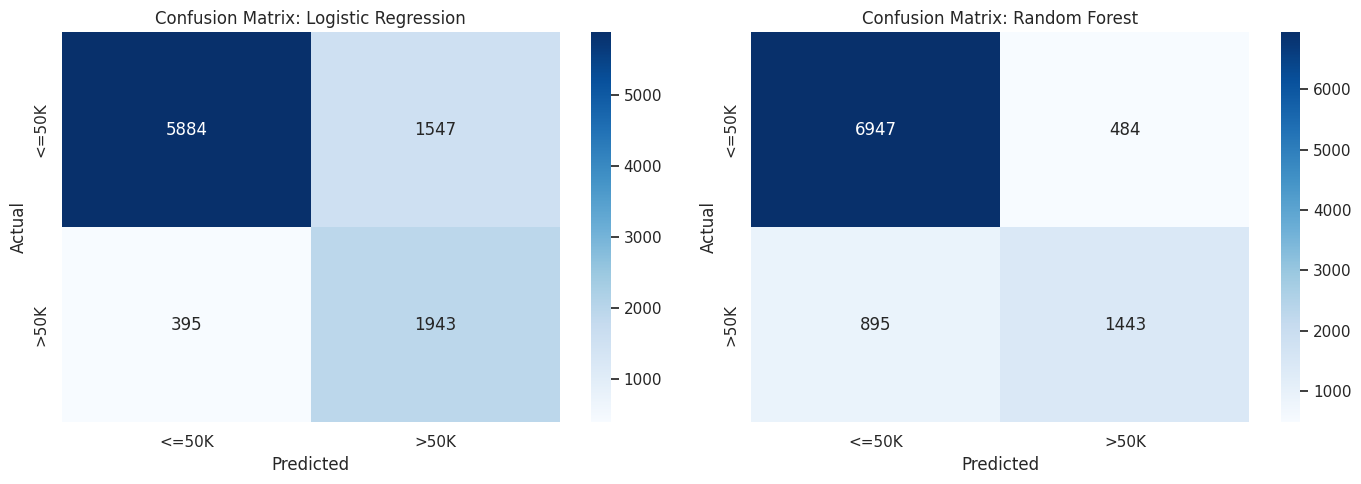

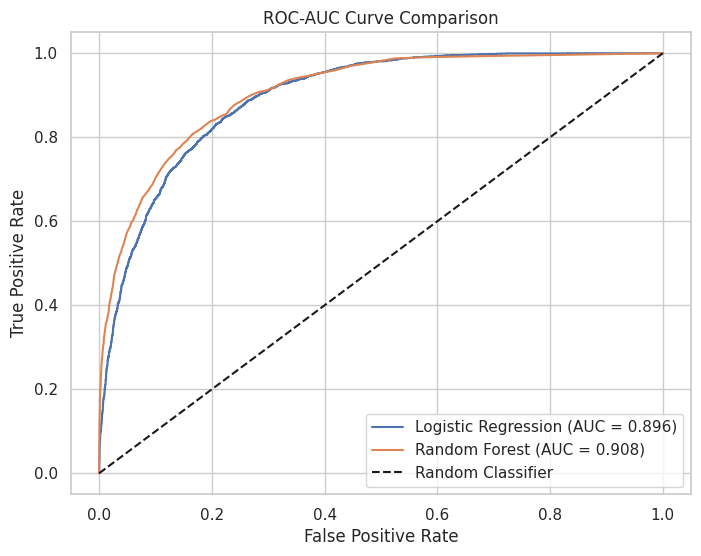

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Instantiate Models with Class Weight Balancing
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# 3. Model Training & Evaluation
results = {}
plt.figure(figsize=(14, 5))

for i, (name, model) in enumerate(models.items(), 1):
    # Fit model
    model.fit(X_train, y_train)

    # Predict classes & probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Compute Metrics
    auc = roc_auc_score(y_test, y_proba)
    results[name] = auc

    print(f"================ {name} Classification Report ================")
    print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))
    print(f"ROC-AUC Score: {auc:.4f}\n")

    # Plot Confusion Matrix
    plt.subplot(1, 2, i)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# 4. Plot ROC Curves Comparison
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 7. Synthesis & Strategic Recommendations

### Key Findings & Model Insights
1. **Model Performance:**
   - **Random Forest** outperformed Logistic Regression in terms of ROC-AUC score and overall F1-score, capturing non-linear feature interactions (such as the relationship between age, education level, and capital gains).
   - Logistic Regression provided a fast, interpretable linear baseline with clear coefficients.

2. **Key Feature Drivers:**
   - **Capital Gains / Losses:** High capital gains are among the strongest positive indicators of belonging to the high-income (>50K) group.
   - **Education & Hours Worked:** Higher educational attainment (`education-num`) combined with working $>40$ hours/week strongly correlates with higher income.

3. **Segmentation (K-Means):**
   - **Cluster Profiles:** The K-Means clusters naturally separated individuals into distinct groups based on age, hours worked per week, and financial investment activity, validating that targeted financial strategies should differ by cluster segment.

### Strategic Recommendations & Action Plan
1. **Financial Product Targeting:** Target investment and wealth management products specifically toward segments with high capital gain indicators and higher education levels.
2. **Class Imbalance Handling:** For production deployment, maintain cost-sensitive learning (`class_weight='balanced'`) or threshold tuning to ensure high recall for high-earning candidates without excessive false positives.
3. **Future Improvements:** Explore non-linear algorithms such as XGBoost or LightGBM and perform hyperparameter tuning using `GridSearchCV` to optimize F1-score further.